# 01 — Hill Climbing y Random Restart

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

Al finalizar este notebook podrás:

- representar un problema de optimización mediante estados, vecinos y una función objetivo;
- implementar **Hill Climbing** para un problema discreto;
- identificar óptimos locales y mesetas;
- usar **Random Restart** para mejorar la exploración.

En los notebooks nos concentraremos en experimentar. La formalización y las propiedades de los algoritmos se presentan en las diapositivas.

## 1. Problema de ubicación de hospitales

Tenemos una cuadrícula con varias casas y queremos ubicar $k$ hospitales. El costo de una solución es la suma de la distancia de cada casa al hospital más cercano.

Usaremos distancia Manhattan por defecto:

$$
d((r_1,c_1),(r_2,c_2)) = |r_1-r_2|+|c_1-c_2|
$$

El problema es

$$
\min_{H} \sum_{c\in C}\min_{h\in H}d(c,h)
$$

- $C$: conjunto de casas.
- $H$: conjunto de hospitales.
- Un vecino se obtiene moviendo un hospital una celda arriba, abajo, izquierda o derecha.

![HillClimbing](https://drive.google.com/uc?export=view&id=1Vb7q8PCqTw-8WkalRWqtB86ovmLhrU1r)


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 8
random.seed(SEED)
np.random.seed(SEED)

In [2]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def total_cost(houses, hospitals):
    return sum(min(manhattan(house, hospital) for hospital in hospitals)
               for house in houses)


def plot_state(height, width, houses, hospitals, title=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.grid(True)

    if houses:
        hr, hc = zip(*houses)
        ax.scatter(hc, hr, marker='s', s=110, label='Casas')
    if hospitals:
        rr, cc = zip(*hospitals)
        ax.scatter(cc, rr, marker='P', s=180, label='Hospitales')

    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    ax.set_title(title or f'Costo = {total_cost(houses, hospitals)}')
    plt.tight_layout()
    plt.show()

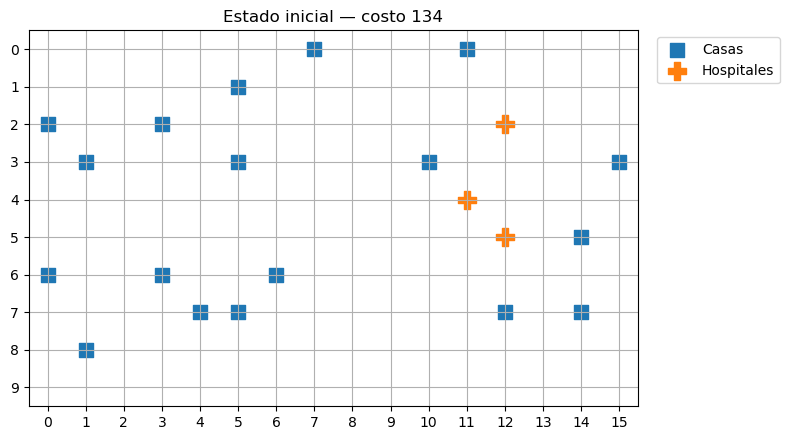

In [3]:
HEIGHT, WIDTH = 10, 16
NUM_HOUSES = 18
NUM_HOSPITALS = 3

all_cells = [(r, c) for r in range(HEIGHT) for c in range(WIDTH)]
houses = set(random.sample(all_cells, NUM_HOUSES))
available = list(set(all_cells) - houses)
initial_hospitals = set(random.sample(available, NUM_HOSPITALS))

plot_state(HEIGHT, WIDTH, houses, initial_hospitals,
           title=f'Estado inicial — costo {total_cost(houses, initial_hospitals)}')

## 2. Vecindario

Para generar estados vecinos moveremos **un hospital a la vez** hacia una celda adyacente disponible.

In [4]:
def neighbors_of_state(height, width, houses, hospitals):
    neighbors = []
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue

            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)

    return neighbors

neighbors = neighbors_of_state(HEIGHT, WIDTH, houses, initial_hospitals)
print('Número de vecinos:', len(neighbors))
print('Costo actual:', total_cost(houses, initial_hospitals))
print('Mejor costo vecino:', min(total_cost(houses, n) for n in neighbors))

Número de vecinos: 12
Costo actual: 134
Mejor costo vecino: 125


## 3. Hill Climbing

En cada iteración:

1. generamos todos los vecinos;
2. calculamos sus costos;
3. nos movemos al vecino con menor costo;
4. detenemos el proceso cuando ningún vecino mejora la solución.

Costo inicial: 134
Costo final: 62
Iteraciones con mejora: 13


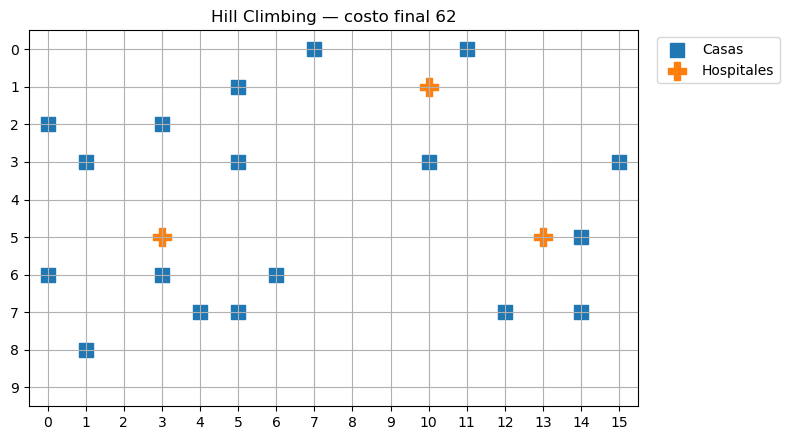

In [5]:
def hill_climbing(height, width, houses, num_hospitals, initial_state=None,
                  max_iterations=200, rng=None, neighbors_fn=None, cost_fn=None):
    rng = rng or random.Random()
    cost_fn = cost_fn or total_cost
    neighbors_fn = neighbors_fn or neighbors_of_state

    available = list(set((r, c) for r in range(height) for c in range(width)) - houses)
    current = set(initial_state) if initial_state is not None else set(rng.sample(available, num_hospitals))
    history = [cost_fn(houses, current)]
    states = [set(current)]

    for _ in range(max_iterations):
        neighbors = neighbors_fn(height, width, houses, current)
        if not neighbors:
            break

        costs = [cost_fn(houses, n) for n in neighbors]
        best_cost = min(costs)
        current_cost = history[-1]

        if best_cost >= current_cost:
            break

        best_neighbors = [n for n, c in zip(neighbors, costs) if c == best_cost]
        current = set(rng.choice(best_neighbors))
        history.append(best_cost)
        states.append(set(current))

    return current, history, states


solution, history, states = hill_climbing(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    initial_state=initial_hospitals,
    rng=random.Random(SEED)
)

print('Costo inicial:', history[0])
print('Costo final:', history[-1])
print('Iteraciones con mejora:', len(history) - 1)
plot_state(HEIGHT, WIDTH, houses, solution,
           title=f'Hill Climbing — costo final {history[-1]}')


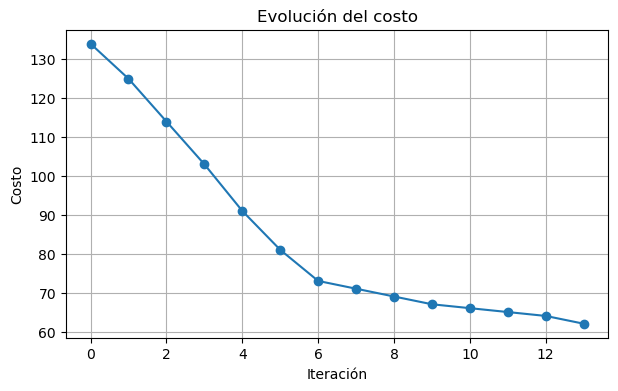

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(range(len(history)), history, marker='o')
plt.xlabel('Iteración')
plt.ylabel('Costo')
plt.title('Evolución del costo')
plt.grid(True)
plt.show()

## 4. Random Restart

Una corrida de Hill Climbing puede terminar en un óptimo local. Random Restart ejecuta el algoritmo desde diferentes estados iniciales y conserva la mejor solución encontrada.

Mejor costo: 56
Reinicio ganador: 2


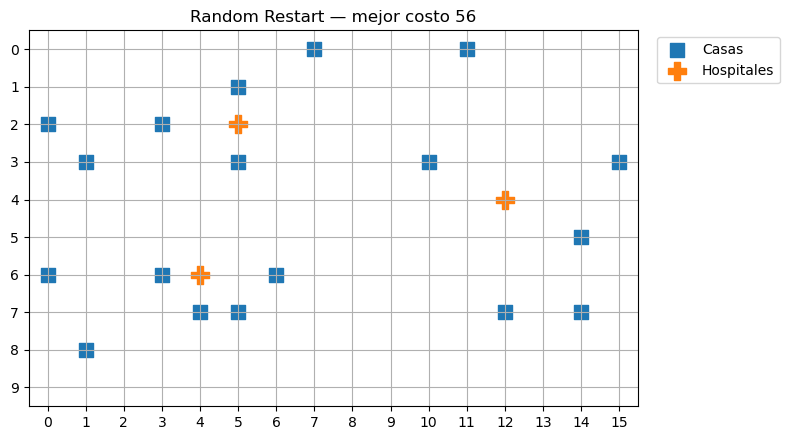

In [8]:
def random_restart(height, width, houses, num_hospitals, restarts=30, seed=0):
    master_rng = random.Random(seed)
    runs = []
    best = None

    for restart in range(restarts):
        run_seed = master_rng.randrange(10**9)
        solution, history, _ = hill_climbing(
            height, width, houses, num_hospitals,
            rng=random.Random(run_seed)
        )
        record = {
            'restart': restart,
            'solution': solution,
            'initial_cost': history[0],
            'final_cost': history[-1],
            'iterations': len(history) - 1
        }
        runs.append(record)
        if best is None or record['final_cost'] < best['final_cost']:
            best = record

    return best, runs

best, runs = random_restart(HEIGHT, WIDTH, houses, NUM_HOSPITALS, restarts=40, seed=SEED)
print('Mejor costo:', best['final_cost'])
print('Reinicio ganador:', best['restart'])
plot_state(HEIGHT, WIDTH, houses, best['solution'],
           title=f'Random Restart — mejor costo {best["final_cost"]}')

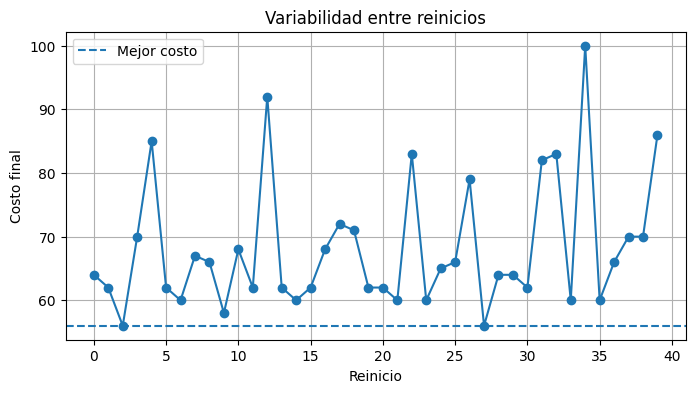

In [ ]:
final_costs = [run['final_cost'] for run in runs]
plt.figure(figsize=(8, 4))
plt.plot(final_costs, marker='o')
plt.axhline(min(final_costs), linestyle='--', label='Mejor costo')
plt.xlabel('Reinicio')
plt.ylabel('Costo final')
plt.title('Variabilidad entre reinicios')
plt.legend()
plt.grid(True)
plt.show()

## Actividades

### Actividad 1 — Distancia euclídea

Modifica la función de costo para usar

$$
d(a,b)=\sqrt{(a_r-b_r)^2+(a_c-b_c)^2}
$$

Compara la ubicación de los hospitales y el costo con la distancia Manhattan.

In [10]:
# TODO: implementa la distancia euclídea y una nueva función de costo.
import math

def euclidean(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])


def total_cost_euclidean(houses, hospitals):
    return sum(min(euclidean(house, hospital) for hospital in hospitals)
               for house in houses)


### Actividad 2 — Número de hospitales

Ejecuta Random Restart para $k\in\{1,2,3,4,5\}$. Registra el mejor costo y discute si agregar hospitales produce siempre la misma reducción.

In [12]:
# Ejecutar Random Restart para k=1..5
results = []
for k in range(1, 6):
    best_k, _ = random_restart(HEIGHT, WIDTH, houses, k, restarts=30, seed=SEED)
    results.append((k, best_k['final_cost']))

results


[(1, 114), (2, 76), (3, 56), (4, 46), (5, 38)]

### Actividad 3 — Diseño del vecindario

Actualmente un hospital solo se mueve una celda. Crea un vecindario que permita movimientos de hasta dos celdas. ¿Mejora el resultado? ¿Cuánto aumenta el número de vecinos evaluados?

In [14]:
# Actividad 3: vecindario extendido (hasta 2 celdas)

def neighbors_of_state_two(height, width, houses, hospitals):
    neighbors = []
    for hospital in hospitals:
        for dr in range(-2, 3):
            for dc in range(-2, 3):
                if dr == 0 and dc == 0:
                    continue
                if abs(dr) + abs(dc) > 2:
                    continue
                candidate = (hospital[0] + dr, hospital[1] + dc)
                if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                    continue
                if candidate in houses or candidate in hospitals:
                    continue

                new_state = set(hospitals)
                new_state.remove(hospital)
                new_state.add(candidate)
                neighbors.append(new_state)

    return neighbors

orig_neighbors = neighbors_of_state(HEIGHT, WIDTH, houses, initial_hospitals)
ext_neighbors = neighbors_of_state_two(HEIGHT, WIDTH, houses, initial_hospitals)
print('Vecinos en estado inicial — original:', len(orig_neighbors), 'extendido:', len(ext_neighbors))

best_solution, history_extended, _ = hill_climbing(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    initial_state=initial_hospitals,
    rng=random.Random(SEED),
    neighbors_fn=neighbors_of_state_two
)

print('Costo inicial con vecindario extendido:', history_extended[0])
print('Costo final con vecindario extendido:', history_extended[-1])
print('Iteraciones con mejora:', len(history_extended) - 1)


Vecinos en estado inicial — original: 12 extendido: 31
Costo inicial con vecindario extendido: 134
Costo final con vecindario extendido: 60
Iteraciones con mejora: 9


## Preguntas de cierre

1. ¿Por qué Hill Climbing no necesita construir todo el espacio de búsqueda?  
    Porque trabaja de forma local: en cada paso genera y evalúa solo los vecinos del estado actual y se mueve hacia el mejor de ellos. No explora ni almacena todas las posibles soluciones, solo va recorriendo un camino a partir de un punto inicial.

2. ¿El resultado depende del estado inicial?  
    Sí. El algoritmo puede quedar atrapado en distintos óptimos locales según la solución inicial, como se ve en las distintas corridas de `random_restart` con costos finales distintos.

3. ¿Random Restart garantiza encontrar el óptimo global?  
    No. Random Restart no lo garantiza, solo incrementa la probabilidad de encontrar mejores soluciones al reiniciar varias veces desde estados distintos.

4. ¿Qué información se pierde al conservar únicamente el mejor vecino?  
    Se pierde información sobre el resto del vecindario: vecinos casi tan buenos, rutas alternativas y posibles plateaus que podrían llevar a soluciones mejores desde pasos distintos al inmediatamente mejor.